# D_S1 — Dense SNR Scatterplot Generation (Comparison Plot)

Generates scatterplots with **dense SNR sampling** (200 levels) for panel B/G style figures.

- **25 families**: 24 signal (F01–F24) + 1 Null (no relationship)
- **201 SNR levels** per family (200 log-spaced + ∞)
- **10 replicates** per (family, SNR)
- Fixed: `x_distribution = even`, `spread_pattern = constant`

Model: `Y = f(X) + σ₀ · ε`, where `σ₀ = √(Var(f) / SNR)`
For Null: `f(x) = 0`, reference `Var = 1.0`, so `σ₀ = 1/√SNR`

In [125]:
from __future__ import annotations

import json
import math
import time
import os
from dataclasses import dataclass, asdict
from itertools import product
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

## Constants and Family Labels

In [126]:
N_PER_CASE = 500
N_SIGNAL_REPLICATES = 10
SIGNAL_VARIANCE_GRID_SIZE = 20_001

# Dense SNR grid: 200 log-spaced points + inf = 201 total
import numpy as _np
SNR_GRID = sorted(_np.geomspace(0.001, 500, 200).tolist()) + [math.inf]
del _np

# Fixed experiment settings
X_DISTRIBUTION = 'even'
SPREAD_PATTERN = 'constant'

# Kept for sample_x compatibility
CLUSTER_OCCUPANCY = 0.4
CLUSTER_BACKGROUND_FRAC = 0.1

MULTI_BRANCH_FAMILIES = {'F23', 'F24'}

OUTPUT_DIR = Path('output/S1')

FAMILY_LABELS: dict[str, dict[str, Any]] = {
    'F01': {
        'family_name': 'Linear positive',
        'equation_presentation': 'y = ax + b, a > 0',
        'basic_label': 'slope a',
        'direction': 'positive',
        'linearity': 'linear',
        'monotonicity': 'monotonic',
        'curvature': 'N/A',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F02': {
        'family_name': 'Linear negative',
        'equation_presentation': 'y = ax + b, a < 0',
        'basic_label': 'slope a',
        'direction': 'negative',
        'linearity': 'linear',
        'monotonicity': 'monotonic',
        'curvature': 'N/A',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F03': {
        'family_name': 'Power convex positive',
        'equation_presentation': 'y = x^p, p > 1',
        'basic_label': 'exponent p',
        'direction': 'positive',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'convex',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F04': {
        'family_name': 'Power convex negative',
        'equation_presentation': 'y = -x^p, p > 1',
        'basic_label': 'exponent p',
        'direction': 'negative',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'concave',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F05': {
        'family_name': 'Power concave positive',
        'equation_presentation': 'y = x^p, 0 < p < 1',
        'basic_label': 'exponent p',
        'direction': 'positive',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'concave',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F06': {
        'family_name': 'Power concave negative',
        'equation_presentation': 'y = -x^p, 0 < p < 1',
        'basic_label': 'exponent p',
        'direction': 'negative',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'convex',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F07': {
        'family_name': 'Saturation positive',
        'equation_presentation': 'y = 1 - exp(-kx)',
        'basic_label': 'rate k',
        'direction': 'positive',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'concave',
        'special_shape': 'saturation',
        'tp_number': '0',
    },
    'F08': {
        'family_name': 'Saturation negative',
        'equation_presentation': 'y = -(1 - exp(-kx))',
        'basic_label': 'rate k',
        'direction': 'negative',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'convex',
        'special_shape': 'saturation',
        'tp_number': '0',
    },
    'F09': {
        'family_name': 'Log positive',
        'equation_presentation': 'y = log(1 + ax)',
        'basic_label': 'scale a',
        'direction': 'positive',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'concave',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F10': {
        'family_name': 'Log negative',
        'equation_presentation': 'y = -log(1 + ax)',
        'basic_label': 'scale a',
        'direction': 'negative',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'convex',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F11': {
        'family_name': 'Exponential positive',
        'equation_presentation': 'y = a^x',
        'basic_label': 'base a, x range',
        'direction': 'positive',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'convex',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F12': {
        'family_name': 'Exponential negative',
        'equation_presentation': 'y = -a^x',
        'basic_label': 'base a, x range',
        'direction': 'negative',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'concave',
        'special_shape': 'none',
        'tp_number': '0',
    },
    'F13': {
        'family_name': 'S-curve positive',
        'equation_presentation': 'logistic (increasing)',
        'basic_label': 'steepness k, center c',
        'direction': 'positive',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'mixed',
        'special_shape': 'S-curve',
        'tp_number': '0',
    },
    'F14': {
        'family_name': 'S-curve negative',
        'equation_presentation': 'logistic (decreasing)',
        'basic_label': 'steepness k, center c',
        'direction': 'negative',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'mixed',
        'special_shape': 'S-curve',
        'tp_number': '0',
    },
    'F15': {
        'family_name': 'Threshold positive',
        'equation_presentation': 'piecewise, b > a',
        'basic_label': 'gap, width, position',
        'direction': 'positive',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'N/A',
        'special_shape': 'threshold',
        'tp_number': '0',
    },
    'F16': {
        'family_name': 'Threshold negative',
        'equation_presentation': 'piecewise, b < a',
        'basic_label': 'gap, width, position',
        'direction': 'negative',
        'linearity': 'nonlinear',
        'monotonicity': 'monotonic',
        'curvature': 'N/A',
        'special_shape': 'threshold',
        'tp_number': '0',
    },
    'F17': {
        'family_name': 'Quadratic peak (Inverted U-shape)',
        'equation_presentation': 'y = -a(x-c)^2 + d',
        'basic_label': 'curvature a, position c',
        'direction': 'none / local',
        'linearity': 'nonlinear',
        'monotonicity': 'non-monotonic',
        'curvature': 'N/A',
        'special_shape': 'peak (Inverted U-shape)',
        'tp_number': '1',
    },
    'F18': {
        'family_name': 'Quadratic valley (U-shape)',
        'equation_presentation': 'y = a(x-c)^2 + d',
        'basic_label': 'curvature a, position c',
        'direction': 'none / local',
        'linearity': 'nonlinear',
        'monotonicity': 'non-monotonic',
        'curvature': 'N/A',
        'special_shape': 'valley (U-shape)',
        'tp_number': '1',
    },
    'F19': {
        'family_name': 'Spike',
        'equation_presentation': 'narrow peak',
        'basic_label': 'width, position',
        'direction': 'none / local',
        'linearity': 'nonlinear',
        'monotonicity': 'non-monotonic',
        'curvature': 'N/A',
        'special_shape': 'local peak',
        'tp_number': '1',
    },
    'F20': {
        'family_name': 'Inverted Spike',
        'equation_presentation': 'piecewise valley',
        'basic_label': 'width, position',
        'direction': 'none / local',
        'linearity': 'nonlinear',
        'monotonicity': 'non-monotonic',
        'curvature': 'N/A',
        'special_shape': 'inverted spike',
        'tp_number': '1',
    },
    'F21': {
        'family_name': 'Cubic',
        'equation_presentation': 'cubic polynomial',
        'basic_label': 'roots, sign, spacing, type = M/W',
        'direction': 'none / mixed',
        'linearity': 'nonlinear',
        'monotonicity': 'non-monotonic',
        'curvature': 'mixed',
        'special_shape': 'cubic / two-turning',
        'tp_number': '2',
    },
    'F22': {
        'family_name': 'Complex non-monotonic functions',
        'equation_presentation': 'Double Gaussian, oscillation, etc.',
        'basic_label': 'shape-specific',
        'direction': 'none / mixed',
        'linearity': 'nonlinear',
        'monotonicity': 'non-monotonic',
        'curvature': 'mixed',
        'special_shape': 'complex',
        'tp_number': 'Multiple',
    },
    'F23': {
        'family_name': 'Two Lines',
        'equation_presentation': 'two linear branches (multi-valued)',
        'basic_label': 'slopes m1,m2, intercepts b1,b2',
        'direction': 'positive',
        'linearity': 'multi-branch linear',
        'monotonicity': 'multi-branch',
        'curvature': 'N/A',
        'special_shape': 'two lines',
        'tp_number': '0',
    },
    'F24': {
        'family_name': 'Line and Parabola',
        'equation_presentation': 'one linear + one quadratic branch (multi-valued)',
        'basic_label': 'slope, curvature, vertex',
        'direction': 'none / local',
        'linearity': 'multi-branch nonlinear',
        'monotonicity': 'multi-branch',
        'curvature': 'mixed',
        'special_shape': 'line + parabola',
        'tp_number': '1',
    },
    'Null': {
        'family_name': 'No relationship',
        'equation_presentation': 'noise only',
        'basic_label': 'none',
        'direction': 'N/A',
        'linearity': 'N/A',
        'monotonicity': 'N/A',
        'curvature': 'N/A',
        'special_shape': 'no relationship',
        'tp_number': 'N/A',
    },
}

label_df = pd.DataFrame.from_dict(FAMILY_LABELS, orient='index').reset_index(names='family_id')
display(label_df)

,family_id,family_name,equation_presentation,basic_label,direction,linearity,monotonicity,curvature,special_shape,tp_number
0,F01,Linear positive,"y = ax + b, a > 0",slope a,positive,linear,monotonic,N/A,none,0
1,F02,Linear negative,"y = ax + b, a < 0",slope a,negative,linear,monotonic,N/A,none,0
2,F03,Power convex positive,"y = x^p, p > 1",exponent p,positive,nonlinear,monotonic,convex,none,0
3,F04,Power convex negative,"y = -x^p, p > 1",exponent p,negative,nonlinear,monotonic,concave,none,0
4,F05,Power concave positive,"y = x^p, 0 < p < 1",exponent p,positive,nonlinear,monotonic,concave,none,0
5,F06,Power concave negative,"y = -x^p, 0 < p < 1",exponent p,negative,nonlinear,monotonic,convex,none,0
6,F07,Saturation positive,y = 1 - exp(-kx),rate k,positive,nonlinear,monotonic,concave,saturation,0
7,F08,Saturation negative,y = -(1 - exp(-kx)),rate k,negative,nonlinear,monotonic,convex,saturation,0
8,F09,Log positive,y = log(1 + ax),scale a,positive,nonlinear,monotonic,concave,none,0
9,F10,Log negative,y = -log(1 + ax),scale a,negative,nonlinear,monotonic,convex,none,0


## Shape Configuration Library

In [127]:
@dataclass(frozen=True)
class ShapeConfig:
    shape_config_id: int
    family_id: str
    variant_name: str
    params: dict[str, Any]

    @property
    def labels(self) -> dict[str, Any]:
        return FAMILY_LABELS[self.family_id]


def build_shape_configs() -> list[ShapeConfig]:
    configs: list[ShapeConfig] = []

    def add(family_id, variant_name, **params):
        configs.append(ShapeConfig(
            shape_config_id=len(configs) + 1,
            family_id=family_id,
            variant_name=variant_name,
            params=params,
        ))

    # One representative config per family (24 signal + 1 null)
    add('F01', 'slope_1',       slope=1.0, intercept=0.0)
    add('F02', 'slope_-1',      slope=-1.0, intercept=0.0)
    add('F03', 'p_2',           p=2.0)
    add('F04', 'p_2',           p=2.0)
    add('F05', 'p_0.5',         p=0.5)
    add('F06', 'p_0.5',         p=0.5)
    add('F07', 'k_5',           k=5.0)
    add('F08', 'k_5',           k=5.0)
    add('F09', 'a_10',          a=10.0)
    add('F10', 'a_10',          a=10.0)
    add('F11', 'base_2_range_3', base=2.0, x_range=3.0)
    add('F12', 'base_2_range_3', base=2.0, x_range=3.0)
    add('F13', 'k_12_c_0.5',   k=12.0, c=0.5, L1=0.0, L2=1.0)
    add('F14', 'k_12_c_0.5',   k=12.0, c=0.5, L1=0.0, L2=1.0)
    add('F15', 'gap_1_d0.03_c0.5', a=0.0, b=1.0, delta=0.03, c=0.5)
    add('F16', 'gap_1_d0.03_c0.5', a=0.0, b=1.0, delta=0.03, c=0.5)
    add('F17', 'a_4_c_0.5',    a=4.0, c=0.5, d=0.0)
    add('F18', 'a_4_c_0.5',    a=4.0, c=0.5, d=0.0)
    add('F19', 'w_0.1_c_0.5',  width=0.1, c=0.5)
    add('F20', 'w_0.1_c_0.5',  width=0.1, c=0.5)
    add('F21', 'cubic_m_center_medium',
        roots=[0.25, 0.5, 0.75], a=18.0, d=0.0,
        cubic_type='M', position='center', spacing='medium')
    add('F22', 'pure_osc_low',  A=1.0, omega=2*math.pi)

    # F23: Two Lines — two linear branches, same origin, different slopes
    add('F23', 'two_lines_diverge',
        m1=0.5, b1=0.0, m2=2.0, b2=0.0)
    # F24: Line and Parabola — line above, small-peak parabola below
    add('F24', 'line_and_para',
        m=2.5, b_line=0.0, a_para=1.6, h=0.5, peak=0.4)

    # Null
    add('Null', 'independent_normal', noise_dist='normal')

    return configs


shape_configs = build_shape_configs()
shape_df = pd.DataFrame([
    {**asdict(cfg), **cfg.labels, 'params_json': json.dumps(cfg.params, sort_keys=True)}
    for cfg in shape_configs
]).drop(columns=['params'])

print(f'Shape configs: {len(shape_configs)}')
display(shape_df[['shape_config_id', 'family_id', 'family_name', 'variant_name']])

Shape configs: 25


,shape_config_id,family_id,family_name,variant_name
0,1,F01,Linear positive,slope_1
1,2,F02,Linear negative,slope_-1
2,3,F03,Power convex positive,p_2
3,4,F04,Power convex negative,p_2
4,5,F05,Power concave positive,p_0.5
5,6,F06,Power concave negative,p_0.5
6,7,F07,Saturation positive,k_5
7,8,F08,Saturation negative,k_5
8,9,F09,Log positive,a_10
9,10,F10,Log negative,a_10


## Function Evaluation

In [128]:
_NEGATIVE_COUNTERPART = {
    'F04': 'F03', 'F06': 'F05', 'F08': 'F07', 'F10': 'F09',
    'F12': 'F11', 'F14': 'F13', 'F16': 'F15',
}


def _triangular_local(x: np.ndarray, center: float, width: float) -> np.ndarray:
    return np.maximum(0.0, 1.0 - np.abs(x - center) / width)


def evaluate_signal(x: np.ndarray, cfg: ShapeConfig,
                    rng: np.random.Generator | None = None) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    p = cfg.params
    fid = cfg.family_id

    if fid in _NEGATIVE_COUNTERPART:
        positive_cfg = ShapeConfig(
            shape_config_id=cfg.shape_config_id,
            family_id=_NEGATIVE_COUNTERPART[fid],
            variant_name=cfg.variant_name,
            params=cfg.params,
        )
        return -evaluate_signal(x, positive_cfg)

    if fid in {'F01', 'F02'}:
        return p['slope'] * x + p.get('intercept', 0.0)
    if fid in {'F03', 'F05'}:
        return x ** p['p']
    if fid == 'F07':
        return 1.0 - np.exp(-p['k'] * x)
    if fid == 'F09':
        return np.log1p(p['a'] * x)
    if fid == 'F11':
        return p['base'] ** (x * p['x_range'])
    if fid == 'F13':
        return p['L1'] + (p['L2'] - p['L1']) / (1.0 + np.exp(-p['k'] * (x - p['c'])))
    if fid == 'F15':
        t = np.clip((x - (p['c'] - p['delta'])) / (2.0 * p['delta']), 0.0, 1.0)
        return p['a'] + (p['b'] - p['a']) * t
    if fid == 'F17':
        return -p['a'] * (x - p['c']) ** 2 + p['d']
    if fid == 'F18':
        return p['a'] * (x - p['c']) ** 2 + p['d']
    if fid == 'F19':
        return _triangular_local(x, p['c'], p['width'])
    if fid == 'F20':
        return 1.0 - _triangular_local(x, p['c'], p['width'])
    if fid == 'F21':
        r1, r2, r3 = p['roots']
        return p['a'] * (x - r1) * (x - r2) * (x - r3) + p['d']
    if fid == 'F22':
        name = cfg.variant_name
        if name.startswith('double_gaussian'):
            return (p['A1'] * np.exp(-((x - p['mu1'])**2) / p['sigma1']**2)
                  + p['A2'] * np.exp(-((x - p['mu2'])**2) / p['sigma2']**2))
        if name.startswith('pure_osc'):
            return p['A'] * np.sin(p['omega'] * x)
        if name.startswith('oscillation_trend'):
            return p['b'] * x + p['A'] * np.sin(p['omega'] * x)
        if name == 'damped_oscillation':
            return p['A'] * np.exp(-p['lambda'] * x) * np.sin(p['omega'] * x)
        if name == 'growing_oscillation':
            return p['A'] * np.exp(p['lambda'] * x) * np.sin(p['omega'] * x)
        if name == 'varying_frequency':
            return p['A'] * np.sin(p['omega'] * x * (1.0 + x))
        raise ValueError(f'Unknown F22 variant: {name}')

    # ── Multi-branch families ──
    if fid == 'F23':
        y0 = p['b1'] + p['m1'] * x
        y1 = p['b2'] + p['m2'] * x
        if rng is None:
            return 0.5 * (y0 + y1)
        z = rng.random(size=len(x)) < 0.5
        return np.where(z, y0, y1)

    if fid == 'F24':
        y_line = p['b_line'] + p['m'] * x
        y_para = p['peak'] - p['a_para'] * (x - p['h']) ** 2
        if rng is None:
            return 0.5 * (y_line + y_para)
        z = rng.random(size=len(x)) < 0.5
        return np.where(z, y_line, y_para)

    if fid == 'Null':
        return np.zeros_like(x, dtype=float)

    raise ValueError(f'Unknown family_id: {fid}')


def get_shape_config(shape_config_id: int) -> ShapeConfig:
    return shape_configs[shape_config_id - 1]

## Sampling and Noise

In [129]:
def _cluster_bounds(n_clusters: int) -> list[tuple[float, float]]:
    cluster_width = CLUSTER_OCCUPANCY / n_clusters
    gap_width = (1.0 - CLUSTER_OCCUPANCY) / (n_clusters + 1)
    bounds = []
    for i in range(n_clusters):
        lo = gap_width * (i + 1) + cluster_width * i
        hi = lo + cluster_width
        bounds.append((lo, hi))
    return bounds


def sample_x(n: int, distribution: str, rng: np.random.Generator) -> np.ndarray:
    if distribution == 'even':
        return rng.uniform(0.0, 1.0, size=n)
    if distribution == 'left_dense':
        return rng.beta(2.0, 5.0, size=n)
    if distribution == 'right_dense':
        return rng.beta(5.0, 2.0, size=n)
    if distribution == 'center_dense':
        return rng.beta(5.0, 5.0, size=n)
    if distribution.startswith('clusters_'):
        n_clusters = int(distribution.split('_')[1])
        bounds = _cluster_bounds(n_clusters)
        is_background = rng.random(size=n) < CLUSTER_BACKGROUND_FRAC
        n_bg = is_background.sum()
        component = rng.integers(0, n_clusters, size=n)
        x = np.empty(n, dtype=float)
        for i, (lo, hi) in enumerate(bounds):
            mask = (~is_background) & (component == i)
            x[mask] = rng.uniform(lo, hi, size=mask.sum())
        x[is_background] = rng.uniform(0.0, 1.0, size=n_bg)
        return x
    raise ValueError(f'Unknown x distribution: {distribution}')


def spread_multiplier(x: np.ndarray, pattern: str) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if pattern == 'constant':
        return np.ones_like(x)
    if pattern == 'increasing':
        return 0.2 + 1.6 * x
    if pattern == 'decreasing':
        return 1.8 - 1.6 * x
    if pattern == 'middle_high':
        return 0.3 + 1.4 * np.exp(-((x - 0.5)**2) / 0.02)
    raise ValueError(f'Unknown spread pattern: {pattern}')


_signal_variance_cache: dict[int, float] = {}

def signal_variance_under_uniform(cfg: ShapeConfig) -> float:
    if cfg.shape_config_id not in _signal_variance_cache:
        if cfg.family_id == 'Null':
            variance = 1.0
        elif cfg.family_id in MULTI_BRANCH_FAMILIES:
            mc_rng = np.random.default_rng(42)
            x_mc = mc_rng.uniform(0.0, 1.0, 100_000)
            y_mc = evaluate_signal(x_mc, cfg, rng=mc_rng)
            variance = float(np.var(y_mc, ddof=0))
        else:
            x_grid = np.linspace(0.0, 1.0, SIGNAL_VARIANCE_GRID_SIZE)
            variance = float(np.var(evaluate_signal(x_grid, cfg), ddof=0))
        _signal_variance_cache[cfg.shape_config_id] = variance
    return _signal_variance_cache[cfg.shape_config_id]


def sigma0_for_snr(cfg: ShapeConfig, snr: float) -> float:
    if math.isinf(float(snr)):
        return 0.0
    variance = signal_variance_under_uniform(cfg)
    if variance <= 0.0:
        return 0.0
    return math.sqrt(variance / float(snr))


X_DIST_LABELS: dict[str, dict[str, str]] = {
    'even': {'density_label': 'even', 'cluster_label': 'no clusters'},
    'left_dense': {'density_label': 'uneven, left-dense', 'cluster_label': 'no clusters'},
    'right_dense': {'density_label': 'uneven, right-dense', 'cluster_label': 'no clusters'},
    'center_dense': {'density_label': 'uneven, center-dense', 'cluster_label': 'no clusters'},
}

def _x_dist_labels(x_distribution: str) -> dict[str, str]:
    if x_distribution in X_DIST_LABELS:
        return X_DIST_LABELS[x_distribution]
    if x_distribution.startswith('clusters_'):
        return {'density_label': 'uneven', 'cluster_label': 'clusters'}
    raise ValueError(f'Unknown x distribution: {x_distribution}')

## Build Case Metadata

In [130]:
def build_cases() -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    for cfg in shape_configs:
        labels = cfg.labels
        for snr in SNR_GRID:
            for rep in range(N_SIGNAL_REPLICATES):
                rows.append({
                    'case_id': len(rows) + 1,
                    'shape_config_id': cfg.shape_config_id,
                    'family_id': cfg.family_id,
                    'family_name': labels['family_name'],
                    'variant_name': cfg.variant_name,
                    'params_json': json.dumps(cfg.params, sort_keys=True),
                    'snr': 'inf' if math.isinf(snr) else float(snr),
                    'spread_pattern': SPREAD_PATTERN,
                    'x_distribution': X_DISTRIBUTION,
                    'category': 'true_null' if cfg.family_id == 'Null' else 'mean_only',
                    'replicate': rep,
                    'n': N_PER_CASE,
                    **{k: v for k, v in labels.items() if k != 'family_name'},
                })

    return pd.DataFrame(rows)


cases_df = build_cases()

print(f'Total cases: {len(cases_df):,}')
print(f'\nCategory breakdown:')
print(cases_df['category'].value_counts().to_string())
print(f'\nFamily breakdown:')
print(cases_df.groupby('family_id').size().to_string())
print(f'\nSNR levels: {len(SNR_GRID)} (range: {SNR_GRID[0]:.4f} — {SNR_GRID[-2]:.1f}, inf)')

Total cases: 50,250

Category breakdown:
category
mean_only    48240
true_null     2010

Family breakdown:
family_id
F01     2010
F02     2010
F03     2010
F04     2010
F05     2010
F06     2010
F07     2010
F08     2010
F09     2010
F10     2010
F11     2010
F12     2010
F13     2010
F14     2010
F15     2010
F16     2010
F17     2010
F18     2010
F19     2010
F20     2010
F21     2010
F22     2010
F23     2010
F24     2010
Null    2010

SNR levels: 201 (range: 0.0010 — 500.0, inf)


## Generate Scatterplot Points

In [131]:
def generate_scatter_xy(case_id: int, replicate: int = 0,
                        cases: pd.DataFrame | None = None,
                        seed_offset: int = 0) -> tuple[np.ndarray, np.ndarray]:
    if cases is None:
        cases = cases_df
    case = cases.loc[cases['case_id'] == case_id].iloc[0]
    cfg = get_shape_config(int(case['shape_config_id']))
    seed = seed_offset + int(case_id) * 1000 + int(replicate)
    rng = np.random.default_rng(seed)

    x = sample_x(N_PER_CASE, str(case['x_distribution']), rng)

    branch_rng = rng if cfg.family_id in MULTI_BRANCH_FAMILIES else None
    y_signal = evaluate_signal(x, cfg, rng=branch_rng)

    snr = math.inf if str(case['snr']) == 'inf' else float(case['snr'])
    sigma0 = sigma0_for_snr(cfg, snr)
    sigma_i = sigma0 * spread_multiplier(x, str(case['spread_pattern']))
    y = y_signal + rng.normal(0.0, sigma_i, size=N_PER_CASE)

    return x.astype(np.float32), y.astype(np.float32)

## Export Dataset

In [132]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
n_total = len(cases_df)

cases_df.to_csv(OUTPUT_DIR / 'cases.csv', index=False)
print(f'Saved cases.csv ({n_total:,} rows)')

x_all = np.empty((n_total, N_PER_CASE), dtype=np.float32)
y_all = np.empty((n_total, N_PER_CASE), dtype=np.float32)

t0 = time.time()
for idx in range(n_total):
    cid = int(cases_df.iloc[idx]['case_id'])
    x_all[idx], y_all[idx] = generate_scatter_xy(cid)
    if (idx + 1) % 10000 == 0:
        elapsed = time.time() - t0
        rate = (idx + 1) / elapsed
        eta = (n_total - idx - 1) / rate
        print(f'  {idx+1:>7,}/{n_total:,}  ({rate:.0f} cases/s, ETA {eta:.0f}s)')

np.savez_compressed(OUTPUT_DIR / 'scatter_points.npz', x=x_all, y=y_all)
elapsed = time.time() - t0
size_mb = (OUTPUT_DIR / 'scatter_points.npz').stat().st_size / 1e6
print(f'Saved scatter_points.npz  shape=({n_total:,}, {N_PER_CASE})  {size_mb:.1f} MB  ({elapsed:.0f}s)')

Saved cases.csv (50,250 rows)
   10,000/50,250  (5189 cases/s, ETA 8s)
   20,000/50,250  (5309 cases/s, ETA 6s)
   30,000/50,250  (5353 cases/s, ETA 4s)
   40,000/50,250  (5389 cases/s, ETA 2s)
   50,000/50,250  (5389 cases/s, ETA 0s)
Saved scatter_points.npz  shape=(50,250, 500)  182.0 MB  (16s)


## Verification

In [133]:
print('=== D Experiment Dataset ===')
print(f'  cases.csv:          {len(cases_df):>10,} rows')
print(f'  scatter_points.npz: {x_all.shape}')
print(f'  SNR levels:         {len(SNR_GRID)}')
print(f'  Replicates/SNR:     {N_SIGNAL_REPLICATES}')
print(f'  Families:           {len(shape_configs)} (24 signal + 1 Null)')
print()
print('Category breakdown:')
print(cases_df['category'].value_counts().to_string())
print()
print('Family × category:')
print(cases_df.groupby(['family_id', 'category']).size().unstack(fill_value=0).to_string())

=== D Experiment Dataset ===
  cases.csv:              50,250 rows
  scatter_points.npz: (50250, 500)
  SNR levels:         201
  Replicates/SNR:     10
  Families:           25 (24 signal + 1 Null)

Category breakdown:
category
mean_only    48240
true_null     2010

Family × category:
category   mean_only  true_null
family_id                      
F01             2010          0
F02             2010          0
F03             2010          0
F04             2010          0
F05             2010          0
F06             2010          0
F07             2010          0
F08             2010          0
F09             2010          0
F10             2010          0
F11             2010          0
F12             2010          0
F13             2010          0
F14             2010          0
F15             2010          0
F16             2010          0
F17             2010          0
F18             2010          0
F19             2010          0
F20             2010          0
F21      

Reproducibility check passed


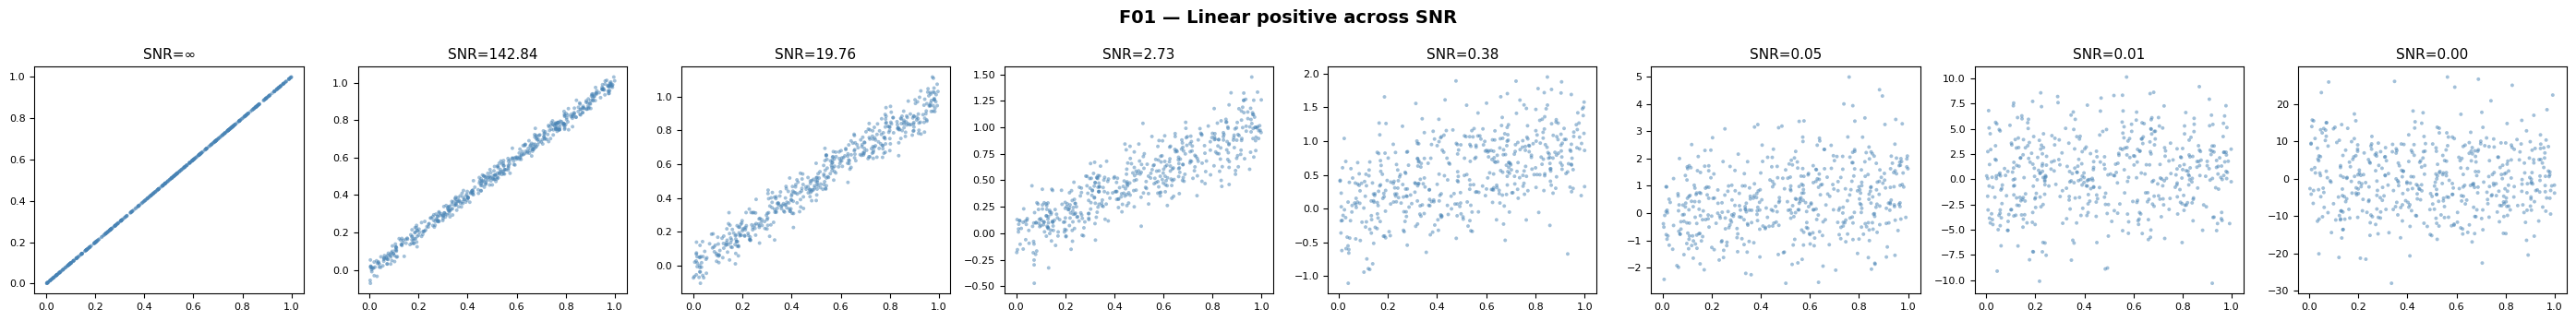

In [134]:
# Spot-check: reproducibility
test_idx = 100
test_cid = int(cases_df.iloc[test_idx]['case_id'])
x_t, y_t = generate_scatter_xy(test_cid)
assert np.allclose(x_all[test_idx], x_t), 'Reproducibility failed'
assert np.allclose(y_all[test_idx], y_t), 'Reproducibility failed'
print('Reproducibility check passed')

# Sample visualization: one family across SNR levels
sample_fam = 'F01'
fam_cases = cases_df[(cases_df['family_id'] == sample_fam) & (cases_df['replicate'] == 0)]
snr_picks = [SNR_GRID[-1]] + [SNR_GRID[i] for i in [180, 150, 120, 90, 60, 30, 0]]  # inf, high→low

fig, axes = plt.subplots(1, len(snr_picks), figsize=(3.5 * len(snr_picks), 3.5))
fig.suptitle(f'{sample_fam} — {shape_configs[0].labels["family_name"]} across SNR',
             fontsize=14, fontweight='bold')

for ax, snr_val in zip(axes, snr_picks):
    snr_str = 'inf' if math.isinf(snr_val) else float(snr_val)
    match = fam_cases[fam_cases['snr'] == snr_str]
    if len(match) == 0:
        ax.set_title(f'SNR={snr_str}\n(not found)', fontsize=10)
        continue
    idx = match.index[0]
    ax.scatter(x_all[idx], y_all[idx], s=8, alpha=0.5, color='steelblue', edgecolors='none')
    ax.set_title(f'SNR={"∞" if math.isinf(snr_val) else f"{snr_val:.2f}"}', fontsize=11)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

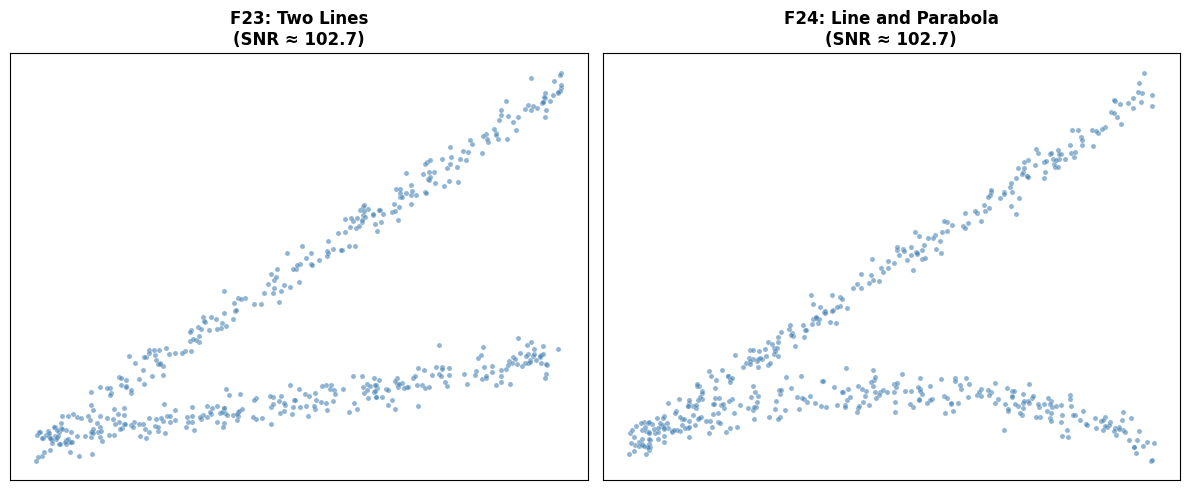

In [135]:
# ── Preview F23 & F24 with moderate noise ──

preview_snr = 100.0
closest_snr = min(
    [s for s in SNR_GRID if not math.isinf(s)],
    key=lambda s: abs(s - preview_snr),
)

preview_families = [
    ('F23', 'Two Lines'),
    ('F24', 'Line and Parabola'),
]

fig, axes = plt.subplots(1, len(preview_families), figsize=(6 * len(preview_families), 5))

for ax, (fam_id, fam_label) in zip(axes, preview_families):
    fam_cases = cases_df[(cases_df['family_id'] == fam_id) &
                         (cases_df['snr'] == closest_snr) &
                         (cases_df['replicate'] == 0)]
    if len(fam_cases) > 0:
        idx = fam_cases.index[0]
        ax.scatter(x_all[idx], y_all[idx], s=14, alpha=0.6,
                   color='steelblue', edgecolors='white', linewidths=0.3)
    ax.set_title(f'{fam_id}: {fam_label}\n(SNR ≈ {closest_snr:.1f})',
                 fontsize=12, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

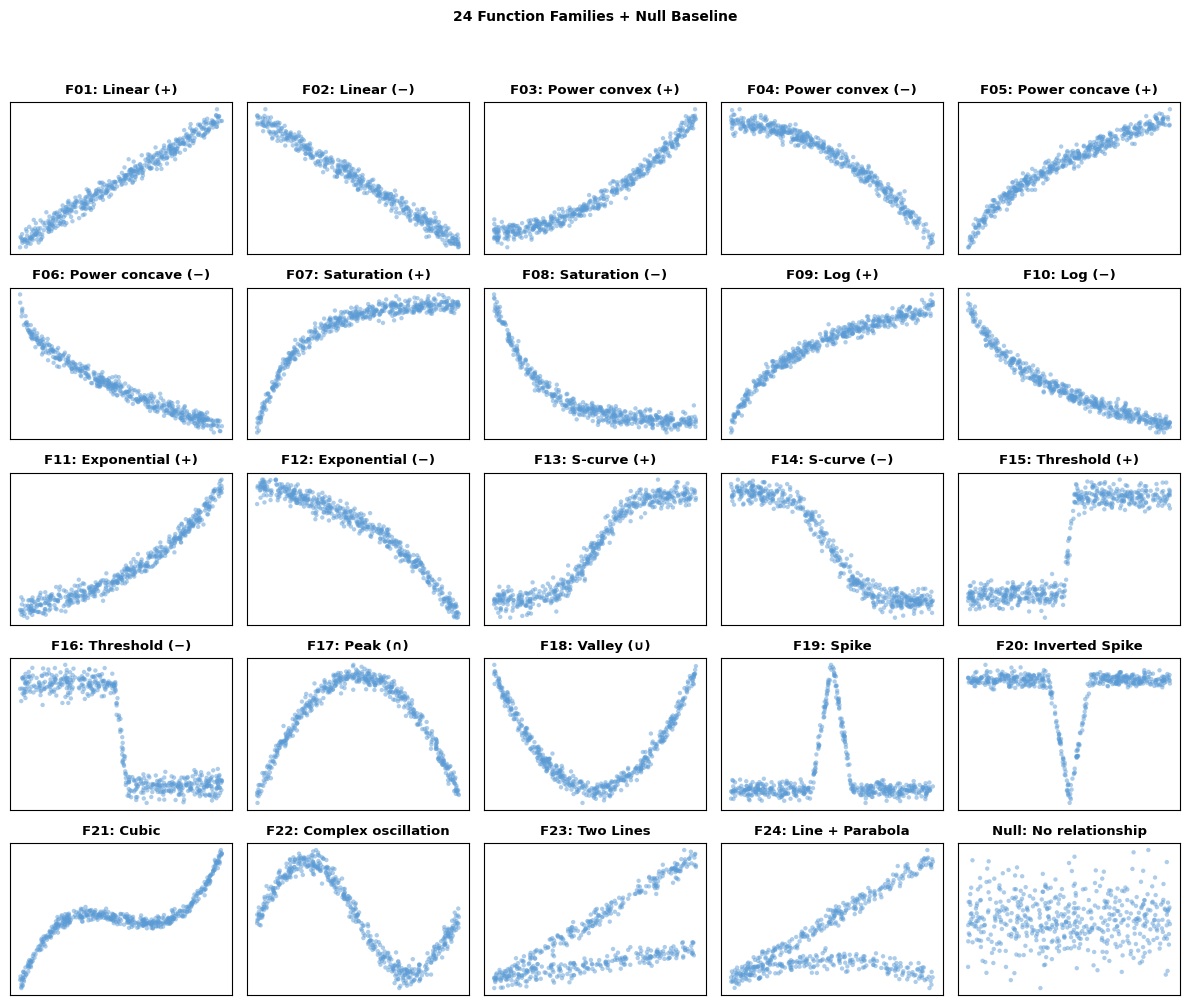

In [152]:
# ── 5×5 Overview: all 25 families ──

USE_SHORT_NAMES = True

overview_snr = 50.0
closest_overview_snr = min(
    [s for s in SNR_GRID if not math.isinf(s)],
    key=lambda s: abs(s - overview_snr),
)

all_family_ids = [f'F{i:02d}' for i in range(1, 25)] + ['Null']

SHORT_NAMES = {
    'F01': 'Linear (+)',       'F02': 'Linear (−)',
    'F03': 'Power convex (+)', 'F04': 'Power convex (−)',
    'F05': 'Power concave (+)','F06': 'Power concave (−)',
    'F07': 'Saturation (+)',   'F08': 'Saturation (−)',
    'F09': 'Log (+)',          'F10': 'Log (−)',
    'F11': 'Exponential (+)',  'F12': 'Exponential (−)',
    'F13': 'S-curve (+)',      'F14': 'S-curve (−)',
    'F15': 'Threshold (+)',    'F16': 'Threshold (−)',
    'F17': 'Peak (∩)',         'F18': 'Valley (∪)',
    'F19': 'Spike',            'F20': 'Inverted Spike',
    'F21': 'Cubic',            'F22': 'Complex oscillation',
    'F23': 'Two Lines',        'F24': 'Line + Parabola',
    'Null': 'No relationship',
}

fig, axes = plt.subplots(5, 5, figsize=(12, 10))
fig.suptitle('24 Function Families + Null Baseline',
             fontsize=10, fontweight='bold', y=1.0)

for idx, (ax, fam_id) in enumerate(zip(axes.flat, all_family_ids)):
    label = SHORT_NAMES[fam_id] if USE_SHORT_NAMES else FAMILY_LABELS[fam_id]['family_name']

    fam_cases = cases_df[(cases_df['family_id'] == fam_id) &
                         (cases_df['snr'] == closest_overview_snr) &
                         (cases_df['replicate'] == 0)]

    if len(fam_cases) > 0:
        case_idx = fam_cases.index[0]
        ax.scatter(x_all[case_idx], y_all[case_idx], s=10, alpha=0.5,
                   color='#5b9bd5', edgecolors='none')

    ax.set_title(f'{fam_id}: {label}', fontsize=9.5, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()